In [1]:
!pip install -q fastmri

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import glob
import h5py

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
def undersample_mask(H, W, accel=4):
    mask = np.zeros((H, W), dtype=np.float32)

    center = H // 2
    num_low = int(H * 0.08)
    mask[center - num_low//2:center + num_low//2] = 1

    for i in range(H):
        if np.random.rand() < 1/accel:
            mask[i] = 1

    return mask

In [4]:
class FastMRIDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(root + '/**/*.h5', recursive=True)

        if len(self.files) == 0:
            raise ValueError(f"Nenhum arquivo encontrado em {root}")

        print(f" {len(self.files)} arquivos")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with h5py.File(self.files[idx], 'r') as f:
            kspace = f['kspace'][()]
            slice_idx = np.random.randint(0, kspace.shape[0])
            kspace = kspace[slice_idx]

        kspace = torch.tensor(kspace, dtype=torch.complex64)
        kspace = torch.view_as_real(kspace).float()

        kspace = (kspace - kspace.mean()) / (kspace.std() + 1e-8)

        Nc, H, W, _ = kspace.shape

        mask_np = undersample_mask(H, W)

        mask = torch.tensor(mask_np).unsqueeze(0).unsqueeze(-1)
        mask = mask.repeat(Nc, 1, 1, 2)

        kspace_us = kspace * mask

        return kspace_us, kspace, torch.tensor(mask_np)

In [5]:
def fft2c(img):
    return torch.fft.fft2(img)

def ifft2c(k):
    return torch.fft.ifft2(k)

In [6]:
def to_image(k):
    k = torch.view_as_complex(k)

    img = torch.abs(torch.fft.ifft2(k))
    img = torch.sqrt((img ** 2).sum(dim=1))

    img = img.unsqueeze(1)

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img

In [7]:
T = 50

beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, 0)

In [8]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)

    a = alpha_bar[t].view(-1,1,1,1)

    return torch.sqrt(a)*x0 + torch.sqrt(1-a)*noise, noise

In [9]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x, t):
        return self.net(x)

In [10]:
def loss_fn(model, x0, x_cond):

    t = torch.randint(0, T, (x0.shape[0],), device=device)

    xt, noise = forward_diffusion(x0, t)

    inp = torch.cat([xt, x_cond], dim=1)

    pred = model(inp, t)

    return ((pred - noise) ** 2).mean()

In [11]:
train_path = '/kaggle/input/datasets/arafatshovon/fastmri-knee-multicoil'

dataset = FastMRIDataset(train_path)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

 194 arquivos


In [12]:
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), 1e-4)

data_iter = iter(loader)

for step in range(3000):

    try:
        kus, kgt, mask = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        kus, kgt, mask = next(data_iter)

    kus, kgt = kus.to(device), kgt.to(device)

    img_gt = to_image(kgt)
    img_us = to_image(kus)

    loss = loss_fn(model, img_gt, img_us)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 50 == 0:
        print(f"Step {step} | Loss {loss.item():.4f}")

Step 0 | Loss 1.0026
Step 50 | Loss 0.6375
Step 100 | Loss 0.4902
Step 150 | Loss 0.5482
Step 200 | Loss 0.3589
Step 250 | Loss 0.0199
Step 300 | Loss 0.0324
Step 350 | Loss 0.0992
Step 400 | Loss 0.0378
Step 450 | Loss 0.0315
Step 500 | Loss 0.0181
Step 550 | Loss 0.0649
Step 600 | Loss 0.6199
Step 650 | Loss 0.0499
Step 700 | Loss 0.0782
Step 750 | Loss 0.8111
Step 800 | Loss 0.0212
Step 850 | Loss 0.0520
Step 900 | Loss 0.0781
Step 950 | Loss 0.0293
Step 1000 | Loss 0.0523
Step 1050 | Loss 0.0317
Step 1100 | Loss 0.0523
Step 1150 | Loss 0.0274
Step 1200 | Loss 0.0295
Step 1250 | Loss 0.0294
Step 1300 | Loss 0.0350
Step 1350 | Loss 0.0305
Step 1400 | Loss 0.1322
Step 1450 | Loss 0.0316
Step 1500 | Loss 0.0257
Step 1550 | Loss 0.0310
Step 1600 | Loss 0.0306
Step 1650 | Loss 0.0277
Step 1700 | Loss 0.0280
Step 1750 | Loss 0.0790
Step 1800 | Loss 0.0324
Step 1850 | Loss 0.0248
Step 1900 | Loss 0.0826
Step 1950 | Loss 0.0274
Step 2000 | Loss 0.0285
Step 2050 | Loss 0.1365
Step 2100 | Los

In [13]:
@torch.no_grad()
def sample_conditioned(model, us_img, mask):

    x = torch.randn_like(us_img).to(device)

    mask = mask.unsqueeze(0).unsqueeze(0).float()
    mask = F.interpolate(mask, size=us_img.shape[-2:], mode='nearest').to(device)

    for t in reversed(range(T)):

        t_tensor = torch.tensor([t], device=device)

        inp = torch.cat([x, us_img], dim=1)
        pred = model(inp, t_tensor)

        a = alpha[t]
        ab = alpha_bar[t]

        x = (1/torch.sqrt(a)) * (x - (1-a)/torch.sqrt(1-ab) * pred)

        k = fft2c(x.squeeze(1))
        kus = fft2c(us_img.squeeze(1))

        k = mask.squeeze(1) * kus + (1-mask.squeeze(1)) * k

        x = torch.real(ifft2c(k)).unsqueeze(1)

        if t > 0:
            x += torch.sqrt(beta[t]) * torch.randn_like(x)

    return x

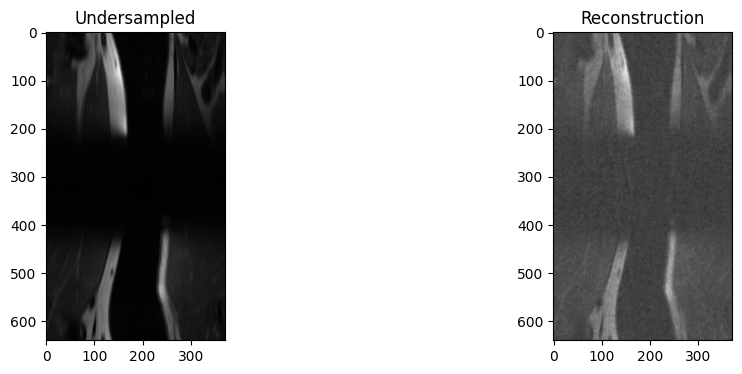

In [15]:
kus, kgt, mask = next(iter(loader))

kus = kus.to(device)

img_us = to_image(kus)

rec = sample_conditioned(model, img_us, mask[0])

#  mover para CPU
img_us = img_us.detach().cpu()
rec = rec.detach().cpu()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_us[0,0], cmap='gray')
plt.title('Undersampled')

plt.subplot(1,2,2)
plt.imshow(rec[0,0], cmap='gray')
plt.title('Reconstruction')

plt.show()

In [16]:
from torchmetrics.functional import peak_signal_noise_ratio as psnr
from torchmetrics.functional import structural_similarity_index_measure as ssim

# pegar exemplo
kus, kgt, mask = next(iter(loader))

kus = kus.to(device)
kgt = kgt.to(device)

# reconstrução
img_us = to_image(kus)
img_gt = to_image(kgt)

rec = sample_conditioned(model, img_us, mask[0])

# mover para cpu
rec = rec.detach().cpu()
img_gt = img_gt.detach().cpu()

# calcular métricas
psnr_val = psnr(rec, img_gt)
ssim_val = ssim(rec, img_gt)

print(f"PSNR: {psnr_val.item():.2f}")
print(f"SSIM: {ssim_val.item():.4f}")

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `peak_signal_noise_ratio` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `peak_signal_noise_ratio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


PSNR: 35.47
SSIM: 0.5075


In [17]:
psnr_list = []
ssim_list = []

for i in range(10):
    kus, kgt, mask = next(iter(loader))

    kus = kus.to(device)
    kgt = kgt.to(device)

    img_us = to_image(kus)
    img_gt = to_image(kgt)

    rec = sample_conditioned(model, img_us, mask[0])

    rec = rec.cpu()
    img_gt = img_gt.cpu()

    psnr_list.append(psnr(rec, img_gt).item())
    ssim_list.append(ssim(rec, img_gt).item())
print("Média de vários exemplos: ")
print("PSNR médio:", sum(psnr_list)/len(psnr_list))
print("SSIM médio:", sum(ssim_list)/len(ssim_list))


Média de vários exemplos: 
PSNR médio: 35.548130416870116
SSIM médio: 0.5510412096977234
